✅ Loaded dataset: reliance_final_model_ready.csv
Shape: (1460, 54)

📊 Top 20 Most Influential Features:
                 Feature  Importance
34        RELIANCE_Lag_1  114.029516
35        RELIANCE_Lag_2   92.631351
36        RELIANCE_Lag_3   62.001059
28               DM_plus   54.589360
39          RELIANCE_MA7   46.952868
29              DM_minus   40.389434
14  RELIANCE_Momentum_10   35.208649
18        RELIANCE_EMA12   32.445136
6             Target_Cls   22.788569
22                  High   19.157248
7                  Close   19.098387
0     RELIANCE.NS_Return   19.098387
23                   Low   19.023425
15     RELIANCE_BB_upper   18.026605
19        RELIANCE_EMA26   16.376671
38       RELIANCE_Lag_10   16.243179
20         RELIANCE_MACD   16.068465
25                  H-PC   13.927528
27                    TR   13.911715
26                  L-PC   13.848826


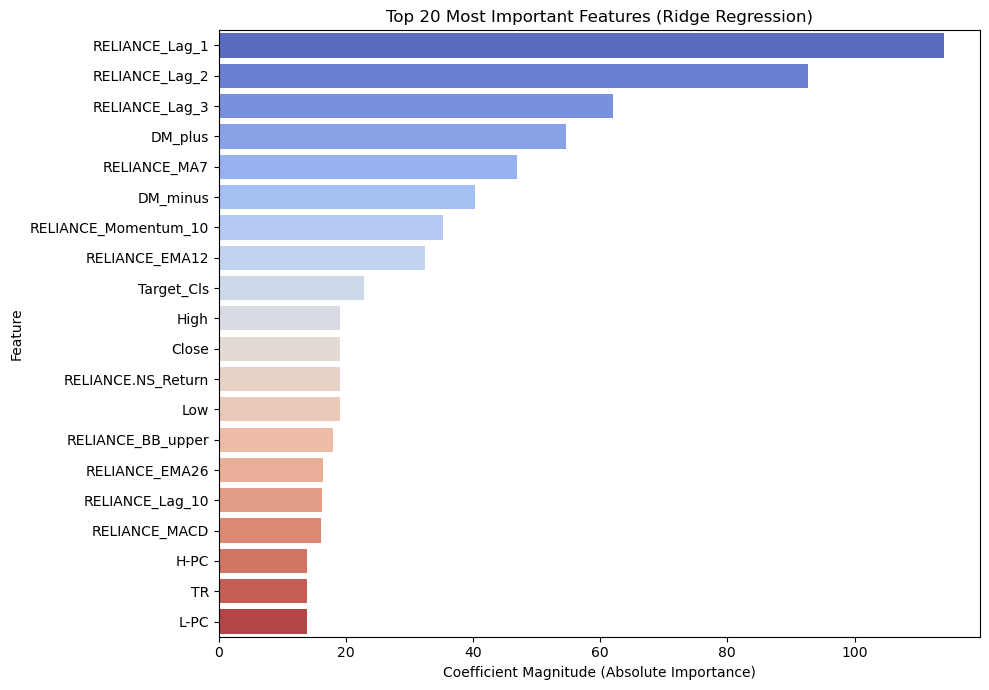


✅ Feature importance plot saved at: C:\JupyterProjects\Stock_ML_Project\Figures\final_feature_importance.png


In [1]:
# =========================================================
# 14B_feature_importance_analysis.ipynb
# Analyze top 20 most important features using Ridge Regression
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings("ignore")

# -------------------------------
# Configuration
# -------------------------------
project_root = Path("C:/JupyterProjects/Stock_ML_Project")
data_dir = project_root / "Data" / "Processed" / "enhanced"
figures_dir = project_root / "Figures"
figures_dir.mkdir(parents=True, exist_ok=True)

# Pick one representative ticker (you can change this later)
file_path = data_dir / "reliance_final_model_ready.csv"

# -------------------------------
# Load Dataset
# -------------------------------
print(f"✅ Loaded dataset: {file_path.name}")
df = pd.read_csv(file_path)
print("Shape:", df.shape)

# Identify target
target_col = next((c for c in ["Target_Reg_y", "Target_Reg"] if c in df.columns), None)
if not target_col:
    raise ValueError("Target column not found!")

# Select numeric features
df = df.replace([np.inf, -np.inf], np.nan)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df = df[numeric_cols].copy().dropna(axis=1, how="all")

# Impute missing values
imputer = SimpleImputer(strategy="mean")
df[df.columns] = imputer.fit_transform(df)

# Separate features and target
y = df[target_col]
X = df.drop(columns=[target_col], errors="ignore")

# -------------------------------
# Train Ridge Regression
# -------------------------------
model = Ridge(alpha=1.0)
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)
model.fit(X_train, y_train)

# Compute feature importance (absolute coefficients)
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": np.abs(model.coef_)
}).sort_values(by="Importance", ascending=False)

top_features = importance.head(20)
print("\n📊 Top 20 Most Influential Features:")
print(top_features)

# -------------------------------
# Plot
# -------------------------------
plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    palette="coolwarm"
)
plt.title("Top 20 Most Important Features (Ridge Regression)")
plt.xlabel("Coefficient Magnitude (Absolute Importance)")
plt.ylabel("Feature")
plt.tight_layout()

# Save figure
save_path = figures_dir / "final_feature_importance.png"
plt.savefig(save_path, dpi=300)
plt.show()

print(f"\n✅ Feature importance plot saved at: {save_path}")


In [2]:
# =========================================================
# 14B_feature_importance_analysis_all.ipynb
# Analyze top 20 most important features using Ridge Regression
# for RELIANCE, TCS, and HDFCBANK
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings("ignore")

# -------------------------------
# Configuration
# -------------------------------
project_root = Path("C:/JupyterProjects/Stock_ML_Project")
data_dir = project_root / "Data" / "Processed" / "enhanced"
figures_dir = project_root / "Figures"
figures_dir.mkdir(parents=True, exist_ok=True)

tickers = {
    "RELIANCE": data_dir / "reliance_final_model_ready.csv",
    "TCS": data_dir / "tcs_final_model_ready.csv",
    "HDFCBANK": data_dir / "hdfcbank_final_model_ready.csv"
}

# -------------------------------
# Helper Function
# -------------------------------
def analyze_feature_importance(ticker, filepath):
    print(f"\n=== Processing {ticker} ===")
    
    if not filepath.exists():
        print(f"  ⚠️ Missing file: {filepath}")
        return
    
    df = pd.read_csv(filepath)
    print(f"  ✅ Loaded: {df.shape}")
    
    # Detect target
    target_col = next((c for c in ["Target_Reg_y", "Target_Reg"] if c in df.columns), None)
    if not target_col:
        print(f"  ⚠️ No Target_Reg found for {ticker}")
        return
    
    # Prepare numeric data
    df = df.replace([np.inf, -np.inf], np.nan)
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    df = df[numeric_cols].copy().dropna(axis=1, how="all")
    
    imputer = SimpleImputer(strategy="mean")
    df[df.columns] = imputer.fit_transform(df)
    
    y = df[target_col]
    X = df.drop(columns=[target_col], errors="ignore")
    
    if X.empty:
        print(f"  ⚠️ No features available for {ticker}")
        return
    
    # Train Ridge model
    model = Ridge(alpha=1.0)
    X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)
    model.fit(X_train, y_train)
    
    # Importance
    importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": np.abs(model.coef_)
    }).sort_values(by="Importance", ascending=False)
    
    top_features = importance.head(20)
    print(f"  📊 Top 5 features for {ticker}:")
    print(top_features.head(5))
    
    # Plot
    plt.figure(figsize=(10, 7))
    sns.barplot(
        data=top_features,
        x="Importance",
        y="Feature",
        palette="coolwarm"
    )
    plt.title(f"Top 20 Most Important Features - {ticker} (Ridge Regression)")
    plt.xlabel("Coefficient Magnitude (Absolute Importance)")
    plt.ylabel("Feature")
    plt.tight_layout()
    
    save_path = figures_dir / f"{ticker.lower()}_feature_importance.png"
    plt.savefig(save_path, dpi=300)
    plt.close()
    
    print(f"  ✅ Saved: {save_path}")

# -------------------------------
# Run for All Tickers
# -------------------------------
for ticker, path in tickers.items():
    analyze_feature_importance(ticker, path)

print("\n🎯 Feature importance analysis completed for all tickers.")
print(f"✅ Figures saved in: {figures_dir}")



=== Processing RELIANCE ===
  ✅ Loaded: (1460, 54)
  📊 Top 5 features for RELIANCE:
           Feature  Importance
34  RELIANCE_Lag_1  114.029516
35  RELIANCE_Lag_2   92.631351
36  RELIANCE_Lag_3   62.001059
28         DM_plus   54.589360
39    RELIANCE_MA7   46.952868
  ✅ Saved: C:\JupyterProjects\Stock_ML_Project\Figures\reliance_feature_importance.png

=== Processing TCS ===
  ✅ Loaded: (1460, 54)
  📊 Top 5 features for TCS:
      Feature  Importance
34  TCS_Lag_1  227.505921
35  TCS_Lag_2  176.562677
36  TCS_Lag_3  133.966894
28    DM_plus  118.945188
39    TCS_MA7   88.361768
  ✅ Saved: C:\JupyterProjects\Stock_ML_Project\Figures\tcs_feature_importance.png

=== Processing HDFCBANK ===
  ✅ Loaded: (1460, 54)
  📊 Top 5 features for HDFCBANK:
                 Feature  Importance
34        HDFCBANK_Lag_1   69.463581
35        HDFCBANK_Lag_2   57.122542
36        HDFCBANK_Lag_3   45.706253
14  HDFCBANK_Momentum_10   34.572245
39          HDFCBANK_MA7   32.397607
  ✅ Saved: C:\JupyterP